In [3]:
import pandas as pd
from tashaphyne.stemming import ArabicLightStemmer
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MaxAbsScaler
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np
from sklearn import svm
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler,MinMaxScaler

In [4]:
import pandas as pd
dataset = pd.read_csv("../datasets/AraPoems_Dataset.csv")

In [5]:
dataset["type_ar"].unique()

array([nan, 'قصائد عامه', 'قصائد رثاء', 'قصائد ذم', 'عموديه',
       'قصائد قصيره', 'قصائد غزل', 'قصائد عتاب', 'قصائد مدح',
       'قصائد هجاء', 'قصائد المعلقات', 'قصائد حزينه', 'قصائد رومنسيه',
       'قصائد حكمة', 'قصائد فراق', 'قصائد نصيحة', 'قصائد شوق',
       'قصائد دينية', 'قصائد صبر', 'قصائد وطنيه', 'قصائد ابتهال',
       'قصائد سياسية', 'قصائد اعتذار', 'قصائد جود وكرم', 'قصائد عدل',
       'قصائد رحمة', 'قصائد الاناشيد'], dtype=object)

In [6]:
list_of_requierd = ["قصائد غزل","قصائد هجاء","قصائد مدح","قصائد رثاء"]

In [7]:
da = dataset[dataset['type_ar'].isin( list_of_requierd)]

In [8]:
da2 = pd.DataFrame()
da2["poem"] = da["first_hemistich"]+" "+da["second_hemistich"]
da2["type"] = da["type_ar"]

In [9]:
da2

,poem,type
36,على مثل ابن مية فانعياه تشق نواعم البشر الجيوبا,قصائد رثاء
37,وكان أبي عتيبة شمريا فلا تلقاه يدخر النصيبا,قصائد رثاء
38,ضروبا للكمي إذا اشمعلت عوان الحرب لا ورعا هيوبا,قصائد رثاء
68,ليس من مات فاستراح بميت إنما الميت ميت الأحياء,قصائد رثاء
71,ليس من مات فاستراح بميت إنما الميت ميت الاحياء,قصائد رثاء
...,...,...
2090662,وتوضع مجمر الركبان أن وجدنا في مراس الحرب خورا,قصائد مدح
2090863,ولي قلب أشد من الرواسي وذكري مثل عرف المسك نامي,قصائد غزل
2090864,وكيف يكون لي عزم وجسمي تراه قد بقي منه الأقل,قصائد غزل
2090865,وأرجع وهي قد ولت خفاف محيرة من الشكوى تكل,قصائد غزل


In [136]:
df_sampled = da2.groupby('type').head(300)
# df_sampled_rest = da2.groupby("type").head(10000)[250:]

In [137]:
# df_sampled_rest["poem"]

In [138]:
df_sampled = df_sampled.dropna()

In [139]:
df_sampled["type"].value_counts()

type
قصائد رثاء    300
قصائد غزل     300
قصائد مدح     300
قصائد هجاء    300
Name: count, dtype: int64

In [151]:
import numpy as np
import tensorflow as tf
from transformers import AutoTokenizer, AutoModel
import torch

class EmbeddingGenerator:
    """
    Generate embeddings for Arabic texts
    """
    def __init__(self, model_name="../akhooli"):
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        self.tokenizer.pad_token = self.tokenizer.eos_token
        self.model = AutoModel.from_pretrained(model_name)
        self.model.eval()
        self.embedding_dim = 768
    
    def get_sentence_embedding(self, text, pooling='cls'):
        """
        Get embedding for a single sentence
        """
        inputs = self.tokenizer(
            text,
            return_tensors='pt',
            padding=True,
            truncation=True,
            # max_length=128
        )
        
        with torch.no_grad():
            outputs = self.model(**inputs)
        
        if pooling == 'mean':
            embedding = outputs.last_hidden_state.mean(dim=1).numpy()[0]
        elif pooling == 'cls':
            embedding = outputs.last_hidden_state[:, 0, :].numpy()[0]
        
        return embedding
    
    def get_batch_embeddings(self, texts, pooling='mean'):
        """
        Get embeddings for multiple sentences
        Returns: numpy array of shape (n_samples, embedding_dim)
        """
        embeddings = []
        for text in texts:
            emb = self.get_sentence_embedding(text, pooling)
            embeddings.append(emb)
        
        return np.array(embeddings)

In [152]:
eg = EmbeddingGenerator()

Loading weights: 100%|██████████| 292/292 [00:00<00:00, 2386.94it/s, Materializing param=wte.weight]             
GPT2Model LOAD REPORT from: ../akhooli
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...23}.attn.masked_bias | UNEXPECTED |  | 
transformer.h.{0...23}.attn.bias        | UNEXPECTED |  | 
lm_head.weight                          | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [153]:
embeddings = eg.get_batch_embeddings(df_sampled["poem"])

In [154]:
len(embeddings[0])

1024

In [155]:
# vectorizer = TfidfVectorizer(ngram_range=(1,6))
# X = vectorizer.fit_transform(df_sampled["poem"])

In [173]:
X_train, X_test, y_train, y_test = train_test_split(embeddings, df_sampled["type"], test_size=0.2, random_state=42)

In [174]:
X_train[0]

array([-0.08286987, -0.420562  , -1.442458  , ...,  0.6124083 ,
       -0.2431684 , -0.10672369], dtype=float32)

In [175]:
clf = Pipeline([
    ('scaler', MinMaxScaler()),
    ('clf', MultinomialNB()),
])

clf.fit(X_train, y_train)

Pipeline(steps=[('scaler', MinMaxScaler()), ('clf', MultinomialNB())])

In [176]:
# df_sampled_rest = df_sampled_rest.dropna()
# # vectorizer = TfidfVectorizer(ngram_range=(1,1))
# X_t = vectorizer.transform(df_sampled_rest["poem"])

In [177]:
accuracy = clf.score(X_train, y_train)
print(f"Train Accuracy: {accuracy * 100:.2f}%")
accuracy = clf.score(X_test, y_test)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

Train Accuracy: 56.56%
Test Accuracy: 52.08%


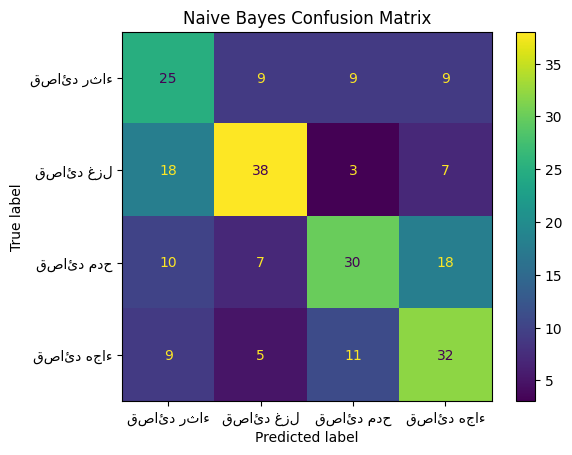

In [178]:
y_pred = clf.predict(X_test)

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title('Naive Bayes Confusion Matrix')
plt.show()

In [179]:
from sklearn.metrics import f1_score
import numpy as np

# Example: After making predictions
# y_true = y_test  # Actual labels
# y_pred = y_pred

# # Calculate F1 score
# f1 = f1_score(y_true, y_pred,average=None)
# print(f"F1 Score: {f1:.3f}")

# For multiclass classification
y_true_multiclass = y_test
y_pred_multiclass = y_pred

# Different averaging methods
f1_macro = f1_score(y_true_multiclass, y_pred_multiclass, average='macro')
f1_micro = f1_score(y_true_multiclass, y_pred_multiclass, average='micro')
f1_weighted = f1_score(y_true_multiclass, y_pred_multiclass, average='weighted')

print(f"Macro F1: {f1_macro:.3f}")
print(f"Micro F1: {f1_micro:.3f}")
print(f"Weighted F1: {f1_weighted:.3f}")

Macro F1: 0.519
Micro F1: 0.521
Weighted F1: 0.524


In [180]:
import numpy as np
from sklearn import svm, datasets
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

scaler = MaxAbsScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


svm_clf = svm.SVC(kernel='rbf', C=1, gamma='scale')

# 5. Train the model
svm_clf.fit(X_train_scaled, y_train)

# 6. Make predictions
y_pred = svm_clf.predict(X_test_scaled)

# 7. Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2%}')


Accuracy: 62.50%


In [181]:
y_pred_train = svm_clf.predict(X_train_scaled)
accuracy = accuracy_score(y_train, y_pred_train)
print(f'Accuracy: {accuracy:.2%}')

Accuracy: 90.62%


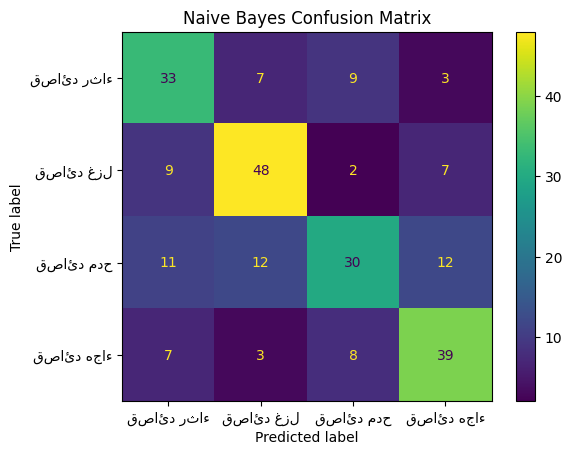

In [182]:
y_pred = svm_clf.predict(X_test_scaled)

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title('Naive Bayes Confusion Matrix')
plt.show()

In [1]:
from sklearn.metrics import f1_score
import numpy as np

# Example: After making predictions
# y_true = y_test  # Actual labels
# y_pred = y_pred

# # Calculate F1 score
# f1 = f1_score(y_true, y_pred,average=None)
# print(f"F1 Score: {f1:.3f}")

# For multiclass classification
y_true_multiclass = y_test
y_pred_multiclass = y_pred

# Different averaging methods
f1_macro = f1_score(y_true_multiclass, y_pred_multiclass, average='macro')
f1_micro = f1_score(y_true_multiclass, y_pred_multiclass, average='micro')
f1_weighted = f1_score(y_true_multiclass, y_pred_multiclass, average='weighted')

print(f"Macro F1: {f1_macro:.3f}")
print(f"Micro F1: {f1_micro:.3f}")
print(f"Weighted F1: {f1_weighted:.3f}")

NameError: name 'y_test' is not defined

In [184]:
# fff = df_sampled['type'].astype('category').cat.codes

In [185]:
# fff